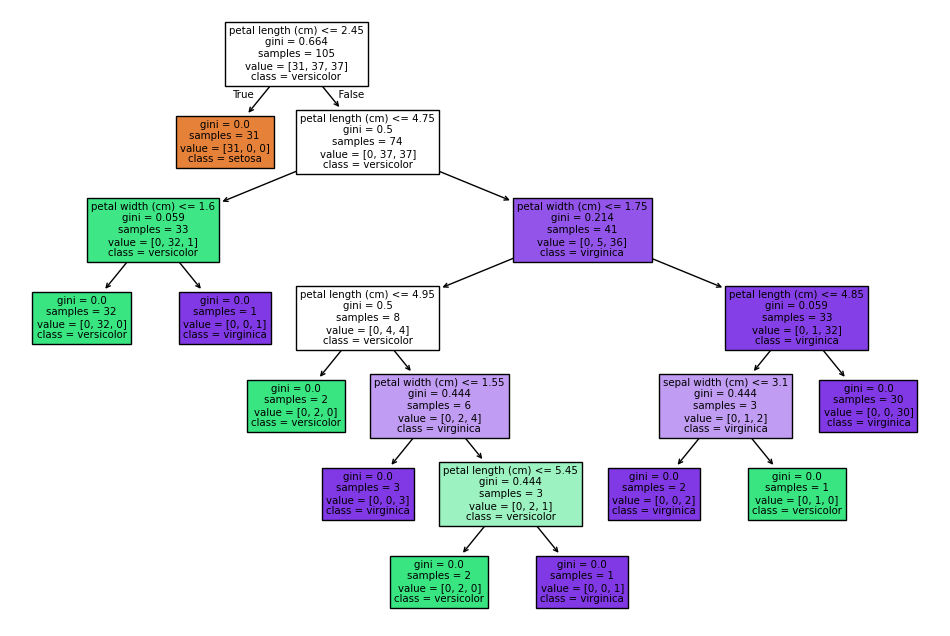

Decision Tree accuracy: 1.0


In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

print("Decision Tree accuracy:", dt.score(X_test, y_test))


In [2]:
for depth in range(1, 6):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    acc = dt.score(X_test, y_test)
    print(f"Max depth={depth}, Accuracy={acc:.3f}")


Max depth=1, Accuracy=0.711
Max depth=2, Accuracy=0.978
Max depth=3, Accuracy=1.000
Max depth=4, Accuracy=1.000
Max depth=5, Accuracy=1.000


In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Loan Random Forest accuracy:", rf.score(X_test, y_test))


Loan Random Forest accuracy: 1.0


In [8]:
import seaborn as sns
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset directly from seaborn
titanic = sns.load_dataset("titanic")

# Select useful features
features = ["pclass", "sex", "age", "sibsp", "fare", "embarked"]
titanic = titanic.dropna(subset=features + ["survived"])

X = titanic[features]
y = titanic["survived"]

# Encode categorical variables
for col in ["sex", "embarked"]:
    X[col] = LabelEncoder().fit_transform(X[col])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest accuracy:", rf.score(X_test, y_test))


Random Forest accuracy: 0.7710280373831776


C:\Users\user2\AppData\Local\Temp\ipykernel_18548\2011760407.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])
C:\Users\user2\AppData\Local\Temp\ipykernel_18548\2011760407.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = LabelEncoder().fit_transform(X[col])


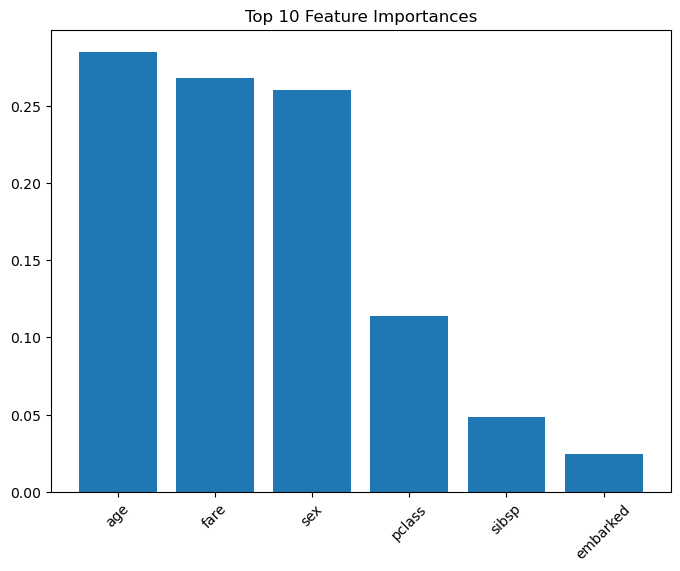

In [9]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_
indices = importances.argsort()[::-1][:10]

# Plot bar chart
plt.figure(figsize=(8,6))
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), [X.columns[i] for i in indices], rotation=45)
plt.title("Top 10 Feature Importances")
plt.show()


In [12]:
import pandas as pd
import numpy as np

# Generate synthetic loan dataset
np.random.seed(42)
n = 500

loan = pd.DataFrame({
    "Income": np.random.randint(2000, 10000, n),
    "CreditScore": np.random.randint(300, 850, n),
    "Age": np.random.randint(18, 65, n),
    "LoanAmount": np.random.randint(1000, 50000, n),
    "Married": np.random.choice(["Yes", "No"], n),
    "Education": np.random.choice(["Graduate", "Not Graduate"], n),
    "Loan_Status": np.random.choice(["Y", "N"], n)  # Target variable
})

loan.head()


,Income,CreditScore,Age,LoanAmount,Married,Education,Loan_Status
0,9270,587,31,34933,Yes,Graduate,N
1,9603,454,43,25951,No,Graduate,Y
2,2860,789,21,33413,No,Graduate,Y
3,7390,685,42,35801,No,Graduate,N
4,7226,403,62,33913,No,Not Graduate,Y
